In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import os
import csv
from sklearn.metrics import accuracy_score

In [ ]:
def load_data(dataset_root='../FORTH_TRACE_DATASET', save_path='all_data.npy'):
    # Se o arquivo já existe, lê direto
    if os.path.exists(save_path):
        print("A carregar os dados do arquivo salvo...")
        return np.load(save_path)
    
    print("A ler os dados do CSV...")
    data_rows = []
    for part_id in range(15):
        dataset_path = f"{dataset_root}/part{part_id}"
        participant_id = part_id
        for dev_id in range(1, 6):
            csv_file = f"{dataset_path}/part{part_id}dev{dev_id}.csv"
            with open(csv_file, 'r', newline='') as f:
                reader = csv.reader(f, delimiter=',')
                for row in reader:
                    arr = np.array(row, dtype=float)
                    new_row = np.hstack((np.array([participant_id], dtype=float), arr))
                    data_rows.append(new_row)

    data = np.vstack(data_rows)
    
    # Salva em .npy para carregar rápido na próxima vez
    np.save(save_path, data)
    print(f"Dados salvos em {save_path}")
    
    return data

# Usar a função
data = load_data()
print(data[:5])
# Carregar dados
data = np.load('all_data.npy')
print(data.shape) # ver dimensão (linhas, colunas)
print(data[:5]) # mostrar as primeiras 5 linhas

A carregar os dados do arquivo salvo...
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.0134e+00  5.0589e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7963e+00  9.3742e+00  2.4460e+00 -1.5618e+00
  -6.6165e-01  5.9730e-01 -3.4274e-01  5.7631e-01  1.0000e+00  5.2542e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.8696e+00  9.3000e+00  2.3514e+00 -1.1877e+00
  -1.2841e+00  1.4212e-01 -3.4476e-01  5.9639e-01  1.0156e+00  5.4495e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.7961e+00  9.3624e+00  2.4584e+00 -5.8399e-01
  -2.0334e+00  4.2912e-01 -3.2863e-01  6.2249e-01  1.0156e+00  5.6448e+02
   1.0000e+00]
 [ 0.0000e+00  1.0000e+00 -1.6768e+00  9.3506e+00  2.4685e+00 -3.7050e-01
  -1.3647e+00  3.7194e-01 -3.3669e-01  6.2048e-01  1.0245e+00  5.8401e+02
   1.0000e+00]]
(3930873, 13)
[[ 0.0000e+00  1.0000e+00 -1.8650e+00  9.3890e+00  2.5812e+00 -1.1418e+00
  -1.1856e+00  8.4998e-01 -3.4476e-01  5.9839e-01  1.013

## 1.1

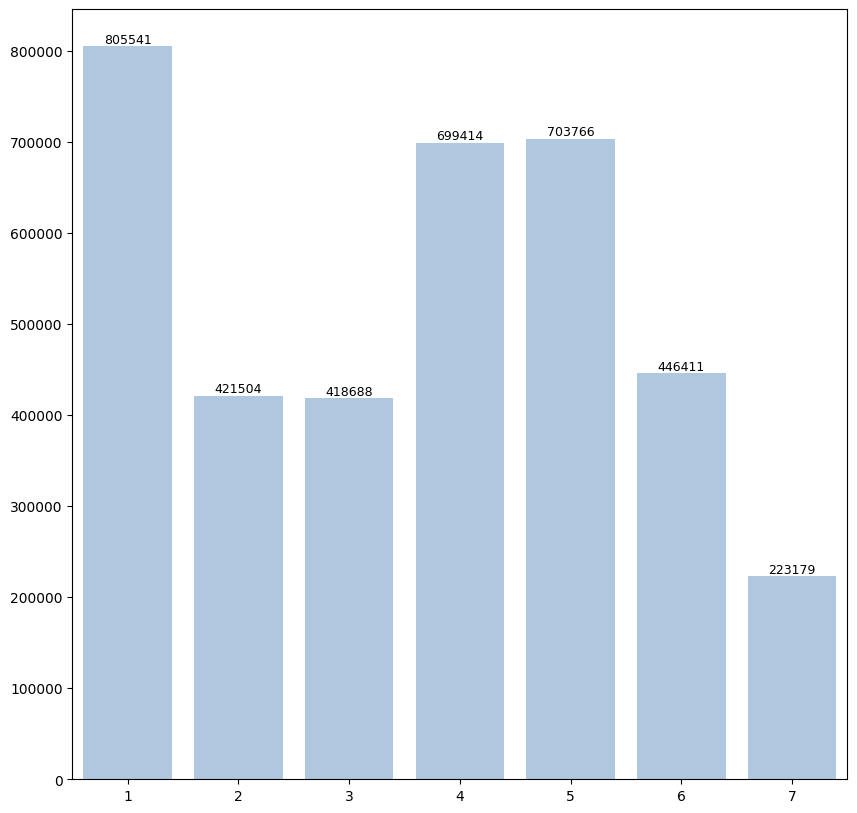

In [4]:
activity_labels = data[:, 12].astype(int)

# Filtrar apenas atividades 1 a 7
mask = (activity_labels >= 1) & (activity_labels <= 7)
data_filtered = data[mask]
filtered_labels = activity_labels[mask]

# Contar exemplos por atividade
atividades, contagens = np.unique(filtered_labels, return_counts=True)

# Plot com seaborn
plt.figure(figsize=(10,10))
grafico = sns.barplot(x=atividades, y=contagens, color='#A7C7E7')
grafico.bar_label(grafico.containers[0], fontsize=9)
plt.show()


## 1.2

In [5]:

def generate_smote_samples(dataset, activity_label, K, k_neighbors=5):
    X = dataset[:, :-1]
    y = dataset[:, -1].astype(int)
    
    current_count = np.sum(y == activity_label)
    
    target_count = current_count + K
    sampling_strategy = {activity_label: target_count}
    
    smote = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X, y)
    
    dataset_augmented = np.hstack((X_res, y_res.reshape(-1,1)))
    return dataset_augmented

## 1.3

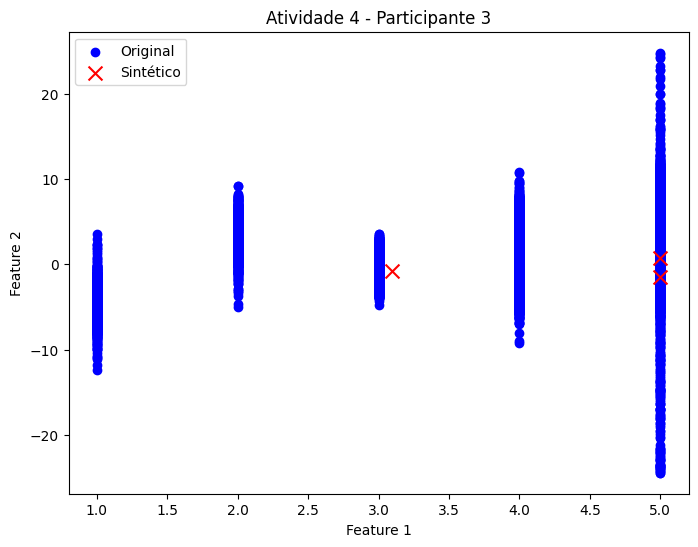

In [6]:
# Filtrar apenas participante 3
participant_id = 3
mask_participant = data[:, 0] == participant_id
data_participant = data[mask_participant]

# Gerar 3 novas amostras para atividade 4
activity_label = 4
data_augmented = generate_smote_samples(data_participant, activity_label=activity_label, K=3)

# Separar exemplos 
data_activity_original = data_participant[data_participant[:, 12] == activity_label]
num_original = data_activity_original.shape[0]

# Filtrar apenas atividade 4
data_activity_augmented = data_augmented[data_augmented[:, 12] == activity_label]
synthetic_samples = data_activity_augmented[num_original:]  # últimos k
original_samples = data_activity_augmented[:num_original]

# Plotar o pedido
plt.figure(figsize=(8,6))
plt.scatter(original_samples[:, 1], original_samples[:, 2], color='blue', label='Original')
plt.scatter(synthetic_samples[:, 1], synthetic_samples[:, 2], color='red', label='Sintético', marker='x', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'Atividade {activity_label} - Participante {participant_id}')
plt.legend()
plt.show()


-------------------------------------------------------------------------------

# Exercício 2 - Embedding Features

In [7]:
#codigo do stor do embedding 
import torch
import numpy as np


def load_model():
  ''' Loads the model from the github repo and obtains just the feature encoder. '''

  repo = 'OxWearables/ssl-wearables'
  # class_num não interessa para extrair features; mas o hub pede este arg
  model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
  model.eval()

  # Passo crucial: ficar só com a parte auto-supervisionada
  # O README diz que há um 'feature_extractor' (pré-treinado) e um 'classifier' (não treinado). :contentReference[oaicite:14]{index=14}
  feature_encoder = model.feature_extractor
  feature_encoder.to("cpu")
  feature_encoder.eval()

  return feature_encoder


def resample_to_30hz_5s(acc_xyz, fs_in_hz):
    """
    acc_xyz: np.ndarray shape (N, 3) em m/s^2 (ou g), amostrado a fs_in_hz (float)
    devolve:
      acc_resampled: np.ndarray shape (M, 3) já a 30 Hz
      fs_target: 30.0
    """
    fs_target = 30.0
    win_size = 5 # in seconds
    t_in = np.arange(acc_xyz.shape[0]) / fs_in_hz
    t_out = np.arange(0, win_size, 1.0/fs_target)

    acc_resampled = np.zeros((len(t_out), 3), dtype=np.float32)
    for axis in range(3):
        acc_resampled[:, axis] = np.interp(t_out, t_in, acc_xyz[:, axis])

    return acc_resampled, fs_target


def acc_segmentation(data):
  ''' Estract ACC segments and their activities '''

  TIMESTAMP_COL = 10
  MIN_SEGMENT_SIZE = 20
  fs_in_hz = 51.5
  win_size = 5000
  start_time = data[0,TIMESTAMP_COL]
  end_time = start_time + win_size

  activities = []
  segments = []

  while end_time < data[-1,TIMESTAMP_COL]:
    mask = (data[:,TIMESTAMP_COL] >= start_time) & (data[:,TIMESTAMP_COL] < end_time)

    if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):

      acc_xyz = data[mask,1:4]
      activity = data[mask, -1][0]
      
      activities.append(activity)
      segments.append( acc_xyz )
      

    start_time = end_time - win_size/2
    end_time = start_time + win_size
  
  
  return segments, activities



# load example file to test embedding
csv_file_path = '../FORTH_TRACE_DATASET/part13/part13dev1.csv'
 
csv_data = np.loadtxt(csv_file_path, delimiter=',')

original_segments, activities = acc_segmentation(csv_data)

resampled_segments = [resample_to_30hz_5s(segment, 51.5)[0] for segment in original_segments]

feature_encoder = load_model()


embeddings_list = []

# reshape segments to [n_segments, dimensions(xyz), time]
x_all = np.transpose( np.array(resampled_segments), (0, 2, 1) )
print(x_all.shape)

# iterate over the resampled segments and pass them 
#    through the model in batches to get the embeddings
batch_size = 5
with torch.no_grad():
    for i in range(0, x_all.shape[0], batch_size):
        xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
        eb = feature_encoder(xb)  # (B, D_embed)
        embeddings_list.append(eb.cpu().numpy())

embeddings = np.concatenate(embeddings_list, axis=0)
print(embeddings.shape)

Using cache found in C:\Users\HP/.cache\torch\hub\OxWearables_ssl-wearables_main


131 Weights loaded
(369, 3, 150)
(369, 512, 1)


In [8]:
# Segmentar sem filtrar ainda
segments, activities = acc_segmentation(csv_data)
print(f"Total de segmentos encontrados: {len(segments)}")

# Filtrar apenas atividades 1 a 7
segments_filtered = []
activities_filtered = []
for seg, act in zip(segments, activities):
    if 1 <= act <= 7:
        segments_filtered.append(seg)
        activities_filtered.append(act)
print(f"Segmentos válidos (classes 1 a 7): {len(segments_filtered)}")

# Resample para 30Hz
resampled_segments = [resample_to_30hz_5s(seg, 51.5)[0] for seg in segments_filtered]

# Preparar formato (N, 3, T)
if len(resampled_segments) == 0:
    print("Nenhum segmento válido encontrado.")
    embeddings_dataset = np.array([])
else:
    x_all = np.array([seg.T for seg in resampled_segments], dtype=np.float32)
    print("Shape após transposição para embeddings:", x_all.shape)

    # Extrair embeddings em batches usando feature_encoder do stor
    embeddings_list = []
    batch_size = 5
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            xb = torch.from_numpy(x_all[i:i+batch_size]).float().to("cpu")
            eb = feature_encoder(xb)
            embeddings_list.append(eb.cpu().numpy())

    embeddings_dataset = np.concatenate(embeddings_list, axis=0)
    print(f"Embeddings dataset shape: {embeddings_dataset.shape}")


Total de segmentos encontrados: 369
Segmentos válidos (classes 1 a 7): 364
Shape após transposição para embeddings: (364, 3, 150)
Embeddings dataset shape: (364, 512, 1)


---------------------------------

# Exercício 3 - Data splitting strategy

### 3.1

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# Labels das atividades
segment_labels = np.array(activities_filtered, dtype=int)

# Subjects de cada segmento: pegamos o participant_id da primeira linha do segmento
segment_subjects = np.array([seg[0, 0] for seg in segments_filtered], dtype=int)

# Features dataset (exemplo: média do acelerômetro por segmento)
features_dataset = np.array([seg.mean(axis=0) for seg in segments_filtered], dtype=np.float32)

# --- Função para split 60-20-20 por sujeito ---
def split_within_subject(X, y, subjects, train_frac=0.6, val_frac=0.2, test_frac=0.2, random_state=42):
    """
    X: dataset (n_samples, ...)
    y: labels (n_samples,)
    subjects: subject_id para cada segmento
    """
    X_train_list, y_train_list = [], []
    X_val_list, y_val_list = [], []
    X_test_list, y_test_list = [], []

    unique_subjects = np.unique(subjects)

    for subj in unique_subjects:
        mask = (subjects == subj)
        X_subj = X[mask]
        y_subj = y[mask]

        # 1) Split treino vs temp (val+test)
        X_train_subj, X_temp_subj, y_train_subj, y_temp_subj = train_test_split(
            X_subj, y_subj, train_size=train_frac, random_state=random_state, shuffle=True
        )

        # 2) Split temp em val e test (proporção 50-50 do temp -> 20% total cada)
        val_frac_adjusted = val_frac / (val_frac + test_frac)
        X_val_subj, X_test_subj, y_val_subj, y_test_subj = train_test_split(
            X_temp_subj, y_temp_subj, train_size=val_frac_adjusted, random_state=random_state, shuffle=True
        )

        # 3) Guardar resultados
        X_train_list.append(X_train_subj)
        y_train_list.append(y_train_subj)
        X_val_list.append(X_val_subj)
        y_val_list.append(y_val_subj)
        X_test_list.append(X_test_subj)
        y_test_list.append(y_test_subj)

    # Concatenar todos os sujeitos
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    X_val = np.concatenate(X_val_list, axis=0)
    y_val = np.concatenate(y_val_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)

    return X_train, y_train, X_val, y_val, X_test, y_test

# --- Aplicando para FEATURES dataset ---
X_train_feat, y_train_feat, X_val_feat, y_val_feat, X_test_feat, y_test_feat = split_within_subject(
    features_dataset, segment_labels, segment_subjects
)

# --- Aplicando para EMBEDDINGS dataset ---
X_train_emb, y_train_emb, X_val_emb, y_val_emb, X_test_emb, y_test_emb = split_within_subject(
    embeddings_dataset, segment_labels, segment_subjects
)

# Verificar shapes
print("FEATURES train/val/test:", X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)
print("EMBEDDINGS train/val/test:", X_train_emb.shape, X_val_emb.shape, X_test_emb.shape)


FEATURES train/val/test: (217, 3) (72, 3) (75, 3)
EMBEDDINGS train/val/test: (217, 512, 1) (72, 512, 1) (75, 512, 1)


### 3.2

In [ ]:
import numpy as np

participants_data = {}
for part_id in range(15):
    # Filtra as linhas correspondentes ao participante
    participants_data[part_id] = data[data[:,0] == part_id]

import numpy as np

# Supondo que já tem o dicionário participants_data
all_subjects = np.array(list(participants_data.keys()))

# Shuffle aleatório (reprodutível)
np.random.seed(42)
shuffled_subjects = np.random.permutation(all_subjects)

# Split 9-3-3
train_subjects, val_subjects, test_subjects = np.split(shuffled_subjects, [9, 12])

# Função para juntar dados dos participantes selecionados
def select_subjects_dict(participants_data, subjects_to_select):
    return np.vstack([participants_data[s] for s in subjects_to_select])

# Criar datasets treino/val/test
train_data = select_subjects_dict(participants_data, train_subjects)
val_data   = select_subjects_dict(participants_data, val_subjects)
test_data  = select_subjects_dict(participants_data, test_subjects)

# Separar features e labels 
X_train = train_data[:, 1:-1]
y_train = train_data[:, -1]

X_val   = val_data[:, 1:-1]
y_val   = val_data[:, -1]

X_test  = test_data[:, 1:-1]
y_test  = test_data[:, -1]

# Verificar shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)


Train: (2359805, 11) (2359805,)
Validation: (771965, 11) (771965,)
Test: (799103, 11) (799103,)


### 3.3

No 3.1 cada participante contribui com dados de treino, validação e teste.
- Ou seja, cada participante está dividido em dados de treino, validação e teste. 
- Isto pode fazer com que o modelo aprenda padrões individuais daquele participante  

No 3.2 cada participante esta em dados de treino, validação e teste.
- Ou seja, cada participante só está num dos dados: ou no de teste, ou de treino ou de validação.
- O modelo aqui não conhece padrões especificos de cada participante e por isso se calhar esta estratégia é mais realista



A melhor estratégia para ser aplicada aos novos participantes é então a 2º porque o modelo ainda não viu dados do mesmo individuo e consegue generalizar para novos participantes.

### 3.4

-------------------------------------------------------------------------------

## 4 - Model learning
We will now train a model to automatically classify the activity of each segment. We will use k-Nearest Neighbors.

### 4.1
Implement a k-Nearest Neighbors classifier (we expect you to implement your own version, but then you can use the sci-kit learn version if you need better performance. See information in [sklearn_KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)).

In [1]:
# Each line is a segment (window of 5 seconds with 50% overlap)
# Inside each windows the first index is a window, second is a column (variable) and each window contains x lines from the original dataset.

class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if len(self.X_train) != len(self.y_train):
            raise ValueError("O Número de amostras em X e y têm de ser igual.")
        
    def _euclidean_distance(self, a, b):
        return np.sqrt(np.sum((a - b) ** 2))
    
    def predict(self, X):
        X_test = np.array(X)
        predictions = []

        for test_point in X_test:
            # Calcukar distâncias para todos os pontos de treino
            distances = np.linalg.norm(self.X_train - test_point, axis=1)
            # Obter os índices dos k vizinhos mais próximos
            k_indices = np.argsort(distances)[:self.k]
            # Obter as labels dos k vizinhos
            k_nearest_labels = self.y_train[k_indices]
            # Aprovar por maioria
            most_common = np.bincount(k_nearest_labels.astype(int)).argmax()
            predictions.append(most_common)

        return np.array(predictions)


my_knn = KNNClassifier(k=5)
my_knn.fit(X_train, y_train)
y_pred = my_knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy do meu KNN: {acc:.4f}")

NameError: name 'X_train' is not defined

### 4.2
Create a function that receives two lists of values: the true labels and predicted labels, and returns a set of classification metrics: confusion matrix, accuracy, f1 score, precision, recall, etc.

-------------------------------------------------------------------------------

## 5 - Model evaluation
For each splitting strategy (2) applied for the 3 versions (all feats, PCA feats, ReliefF feats) of the 2 datasets (features, embeddings), train the classifier and evaluate its results:

### 5.1 Hyperparameter tuning
Select the best value of k using only the train and validation data. Then, with the best k, retrain with the dataset (train + validation) and evaluate on the test set.

### 5.2 Report and analyse results
Check the confusion matrices and observe which activities are harder to classify. Which dataset worked best (features vs embeddings)? Did feature selection improve the performance? Etc.

### 5.3 Perform hypothesis testing to compare the models
Is the best model statistically significantly better than the others? Justify the choice of the statistical tests you use. (NOTE: repeat the train-validation-test split several times to obtain the performance distributions of each model)

-------------------------------------------------------------------------------

## 6 - Deployment
Pick the best model from question 5 and make a function that receives a numpy array of shape 256 lines and 9 columns (acc x y z, gyr x y z, mag x y z) and performs all the necessary steps to return a classification from the model (normalization, feature extraction / embeddings generation, [PCA, Feature Selection], classification).

-------------------------------------------------------------------------------

## 7 - Go further
Discuss what can be done more to improve your classification system.

### 7.1 (BONUS) Implement and evaluate some of those ideas!